# Flight Price Prediction

### The goal of this project is to predict flight prices using machine learning techniques.

The goal is to develop a tool that provides accurate flight prices. However, the company faces the challenge of predicting flight prices with absolute precision, given the various factors that can increase the price and make it uncompetitive or inaccurate. Therefore, we will use a Machine Learning model to accurately predict airline ticket prices using flight-related variables such as airline, number of layovers, duration, and how far in advance the purchase is made.

Different regression algorithms will be tested and evaluated using metrics such as MAE, RMSE, and R². The selected model will be the one that best captures the relationship between the variables and the ticket price, allowing us to generate useful estimates for an online travel platform.

We will begin by cleaning the data to remove null values, eliminate duplicates, review data types, and transform categorical variables. Subsequently, we will perform an exploratory analysis to determine the influential variables. We will then prepare the data to train our model, training several models to confirm which is the most effective for our case. By evaluating the models, we will choose the one that best suits our needs. Finally, we will optimize the model and provide the conclusion of our project.

#### Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
Business = pd.read_excel("business.xlsx")
Economy = pd.read_excel("economy.xlsx")

print("Business dataset")
display(Business.head())

print("Economy dataset")
display(Economy.head())

Business dataset


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,2022-02-11,Air India,AI,868,18:00:00,Delhi,02h 00m,non-stop,20:00:00,Mumbai,25612
1,2022-02-11,Air India,AI,624,19:00:00,Delhi,02h 15m,non-stop,21:15:00,Mumbai,25612
2,2022-02-11,Air India,AI,531,20:00:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45:00,Mumbai,42220
3,2022-02-11,Air India,AI,839,21:25:00,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,44450
4,2022-02-11,Air India,AI,544,17:15:00,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,46690


Economy dataset


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,2022-02-11,SpiceJet,SG,8709,18:55:00,Delhi,02h 10m,non-stop,21:05:00,Mumbai,5953
1,2022-02-11,SpiceJet,SG,8157,06:20:00,Delhi,02h 20m,non-stop,08:40:00,Mumbai,5953
2,2022-02-11,AirAsia,I5,764,04:25:00,Delhi,02h 10m,non-stop,06:35:00,Mumbai,5956
3,2022-02-11,Vistara,UK,995,10:20:00,Delhi,02h 15m,non-stop,12:35:00,Mumbai,5955
4,2022-02-11,Vistara,UK,963,08:50:00,Delhi,02h 20m,non-stop,11:10:00,Mumbai,5955


We load the necessary datasets; however, we combine them to make data exploration and cleaning easier.

In [3]:
## Combine
Vuelos = pd.concat([Business, Economy], axis=0)

##We restarted the index
Vuelos.reset_index(drop=True, inplace=True)

##We verified the final result
print(Vuelos.shape)
Vuelos.head()

(300261, 11)


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,2022-02-11,Air India,AI,868,18:00:00,Delhi,02h 00m,non-stop,20:00:00,Mumbai,25612
1,2022-02-11,Air India,AI,624,19:00:00,Delhi,02h 15m,non-stop,21:15:00,Mumbai,25612
2,2022-02-11,Air India,AI,531,20:00:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45:00,Mumbai,42220
3,2022-02-11,Air India,AI,839,21:25:00,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,44450
4,2022-02-11,Air India,AI,544,17:15:00,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,46690


In [4]:
## We reviewed the types of data we have in our dataset

Vuelos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300261 entries, 0 to 300260
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date        300261 non-null  datetime64[ns]
 1   airline     300261 non-null  object        
 2   ch_code     300261 non-null  object        
 3   num_code    300261 non-null  int64         
 4   dep_time    300261 non-null  object        
 5   from        300261 non-null  object        
 6   time_taken  300261 non-null  object        
 7   stop        300261 non-null  object        
 8   arr_time    300261 non-null  object        
 9   to          300261 non-null  object        
 10  price       300261 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 25.2+ MB


We proceed to correct the data types to facilitate processing.

In [5]:
## We convert values to categorical ones

cat_cols = ["airline", "ch_code", "from", "to"]

for col in cat_cols:
    Vuelos[col] = Vuelos[col].astype("category")

## Price
Vuelos["price"] = (Vuelos["price"].astype(str).str.replace(",", ""))
Vuelos["price"] = pd.to_numeric(Vuelos["price"], errors="coerce")

## flight duration
Vuelos["time_taken"] = Vuelos["time_taken"].astype(str).str.extract(r'(\d+)').astype(float)

##Scales
Vuelos["stop"] = Vuelos["stop"].astype(str).str.extract(r'(\d+)').fillna(0).astype(int)

##Hours
Vuelos["dep_time"] = Vuelos["dep_time"].apply(lambda x: x.hour)
Vuelos["arr_time"] = Vuelos["arr_time"].apply(lambda x: x.hour)

In [6]:
## We set time slots.

Vuelos["dep_period"] = pd.cut(Vuelos["dep_time"],bins=[0,6,12,18,24],labels=["madrugada","mañana","tarde","noche"],include_lowest=True) 
Vuelos["arr_period"] = pd.cut(Vuelos["arr_time"],bins=[0,6,12,18,24],labels=["madrugada","mañana","tarde","noche"],include_lowest=True)

Establishing a time slot will reduce the variables and facilitate classification.

In [7]:
## We confirm that the data has been corrected

Vuelos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300261 entries, 0 to 300260
Data columns (total 13 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date        300261 non-null  datetime64[ns]
 1   airline     300261 non-null  category      
 2   ch_code     300261 non-null  category      
 3   num_code    300261 non-null  int64         
 4   dep_time    300261 non-null  int64         
 5   from        300261 non-null  category      
 6   time_taken  300261 non-null  float64       
 7   stop        300261 non-null  int32         
 8   arr_time    300261 non-null  int64         
 9   to          300261 non-null  category      
 10  price       300261 non-null  int64         
 11  dep_period  300261 non-null  category      
 12  arr_period  300261 non-null  category      
dtypes: category(6), datetime64[ns](1), float64(1), int32(1), int64(4)
memory usage: 16.6 MB


In [8]:
Vuelos.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,dep_period,arr_period
0,2022-02-11,Air India,AI,868,18,Delhi,2.0,0,20,Mumbai,25612,tarde,noche
1,2022-02-11,Air India,AI,624,19,Delhi,2.0,0,21,Mumbai,25612,noche,noche
2,2022-02-11,Air India,AI,531,20,Delhi,24.0,1,20,Mumbai,42220,noche,noche
3,2022-02-11,Air India,AI,839,21,Delhi,26.0,1,23,Mumbai,44450,noche,noche
4,2022-02-11,Air India,AI,544,17,Delhi,6.0,1,23,Mumbai,46690,tarde,noche


In [9]:
## We validate the set size
Vuelos.shape

(300261, 13)

In [10]:
## We validate null values

print("Null values in the data set")
print(Vuelos.isnull().sum())

Null values in the data set
date          0
airline       0
ch_code       0
num_code      0
dep_time      0
from          0
time_taken    0
stop          0
arr_time      0
to            0
price         0
dep_period    0
arr_period    0
dtype: int64


In [11]:
## We detected duplicate values

print("Duplicate values:", Vuelos.duplicated().sum())

Duplicate values: 1867


In [12]:
##We validated the reason why there are so many duplicates.

Vuelos[Vuelos.duplicated()].head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,dep_period,arr_period
388,2022-02-15,Vistara,UK,819,14,Delhi,6.0,1,20,Mumbai,53164,tarde,noche
394,2022-02-15,Vistara,UK,801,9,Delhi,11.0,1,20,Mumbai,53164,mañana,noche
416,2022-02-15,Vistara,UK,815,8,Delhi,12.0,1,20,Mumbai,60601,mañana,noche
495,2022-02-16,Vistara,UK,819,14,Delhi,6.0,1,20,Mumbai,53164,tarde,noche
501,2022-02-16,Vistara,UK,801,9,Delhi,11.0,1,20,Mumbai,53164,mañana,noche


This exploration shows us that there are 1867 duplicates; however, we see that not all rows are the same, which is why the duplicates cannot be eliminated, since they are independent data.

### Exploratory Data Analysis

In [14]:
 ## It helps us detect extreme values

Vuelos.describe()

,date,num_code,dep_time,time_taken,stop,arr_time,price
count,300261,300261.000000,300261.000000,300261.000000,300261.000000,300261.000000,300261.000000
mean,2022-03-08 00:06:26.447790336,1417.771709,12.983531,11.775642,0.924213,15.238935,20883.717666
min,2022-02-11 00:00:00,101.000000,0.000000,0.000000,0.000000,0.000000,1105.000000
25%,2022-02-25 00:00:00,637.000000,8.000000,6.000000,1.000000,10.000000,4783.000000
50%,2022-03-08 00:00:00,818.000000,12.000000,11.000000,1.000000,17.000000,7425.000000
75%,2022-03-20 00:00:00,927.000000,18.000000,16.000000,1.000000,20.000000,42521.000000
max,2022-03-31 00:00:00,9991.000000,23.000000,49.000000,2.000000,23.000000,123071.000000
std,NaN,1974.514439,5.363186,7.199275,0.398188,6.050231,22695.911266


We created a box plot to detect outliers and data distribution.

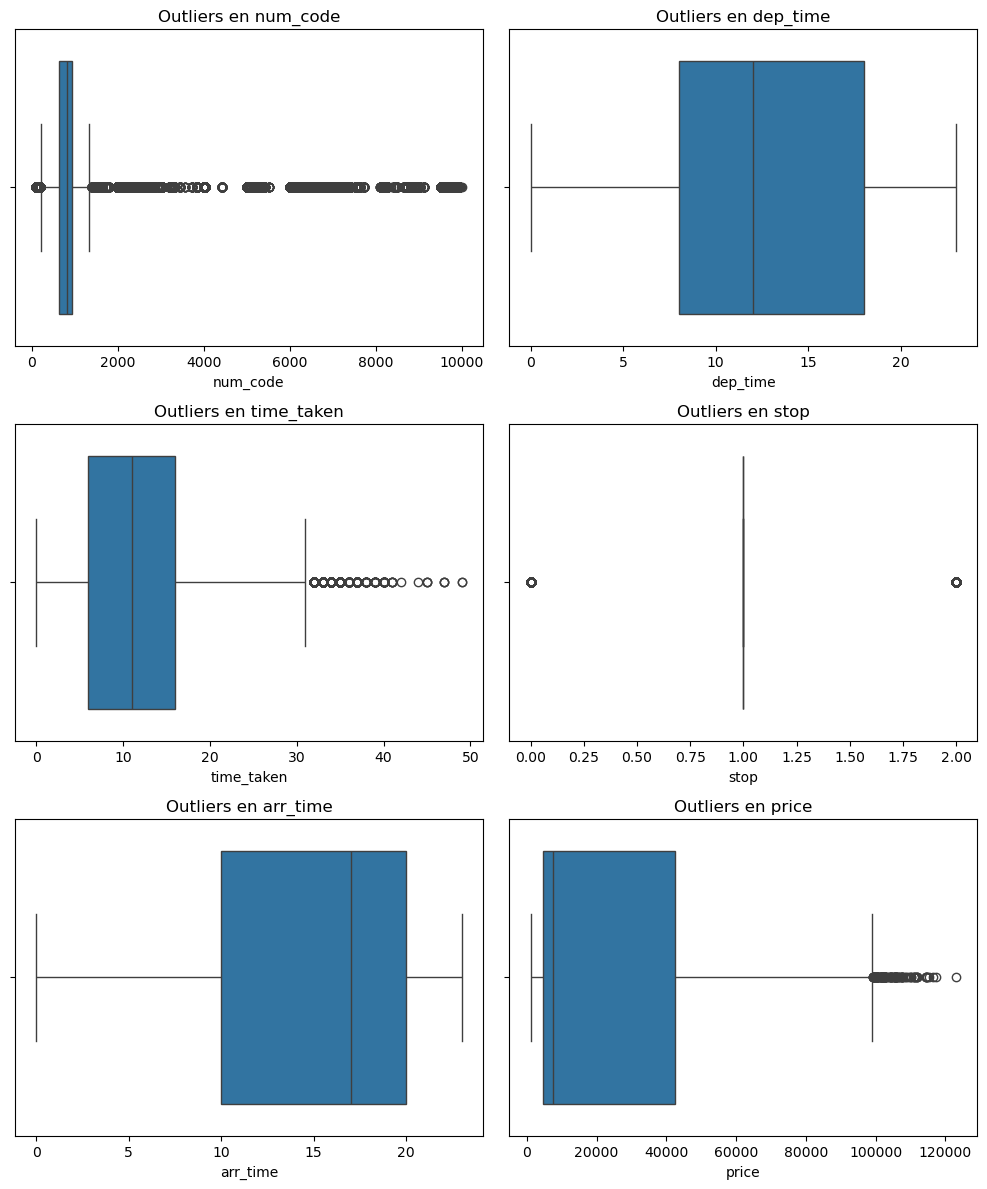

In [15]:
num_cols_vuelos = Vuelos.select_dtypes(include=np.number).columns

n_cols = 2
n_rows = int(np.ceil(len(num_cols_vuelos) / n_cols))

plt.figure(figsize=(10, 4*n_rows))

for i, col in enumerate(num_cols_vuelos, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=Vuelos[col])
    plt.title(f"Outliers en {col}")

plt.tight_layout()
plt.show()

We evaluated the outliers in general, and the variables Price, time_taken, and num_cod showed the highest number of outliers. This can be explained as follows:

Flight duration: This could be due to factors such as the distribution of layovers, indirect routes, or potential data quality issues. Therefore, we decided to retain these values to gain a complete understanding of their potential impact.

Price: This could be explained by factors such as premium airlines, last-minute bookings, longer routes, or flights with fewer layovers. Therefore, we decided to retain these values, as removing them could eliminate important information about highly relevant cases.

<Axes: xlabel='price', ylabel='Count'>

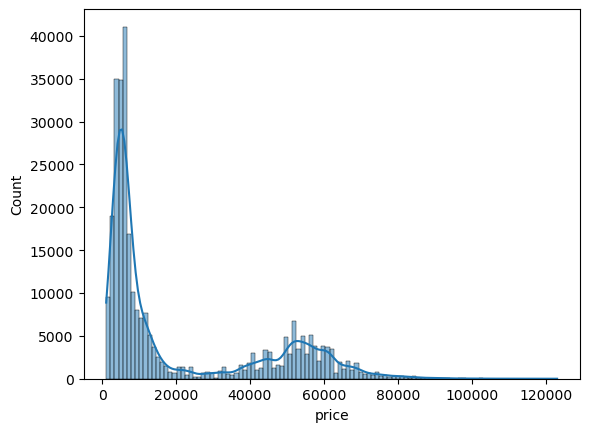

In [16]:
sns.histplot(Vuelos[col], kde=True)

The price distribution is heavily skewed to the right, indicating the presence of high-value outliers.

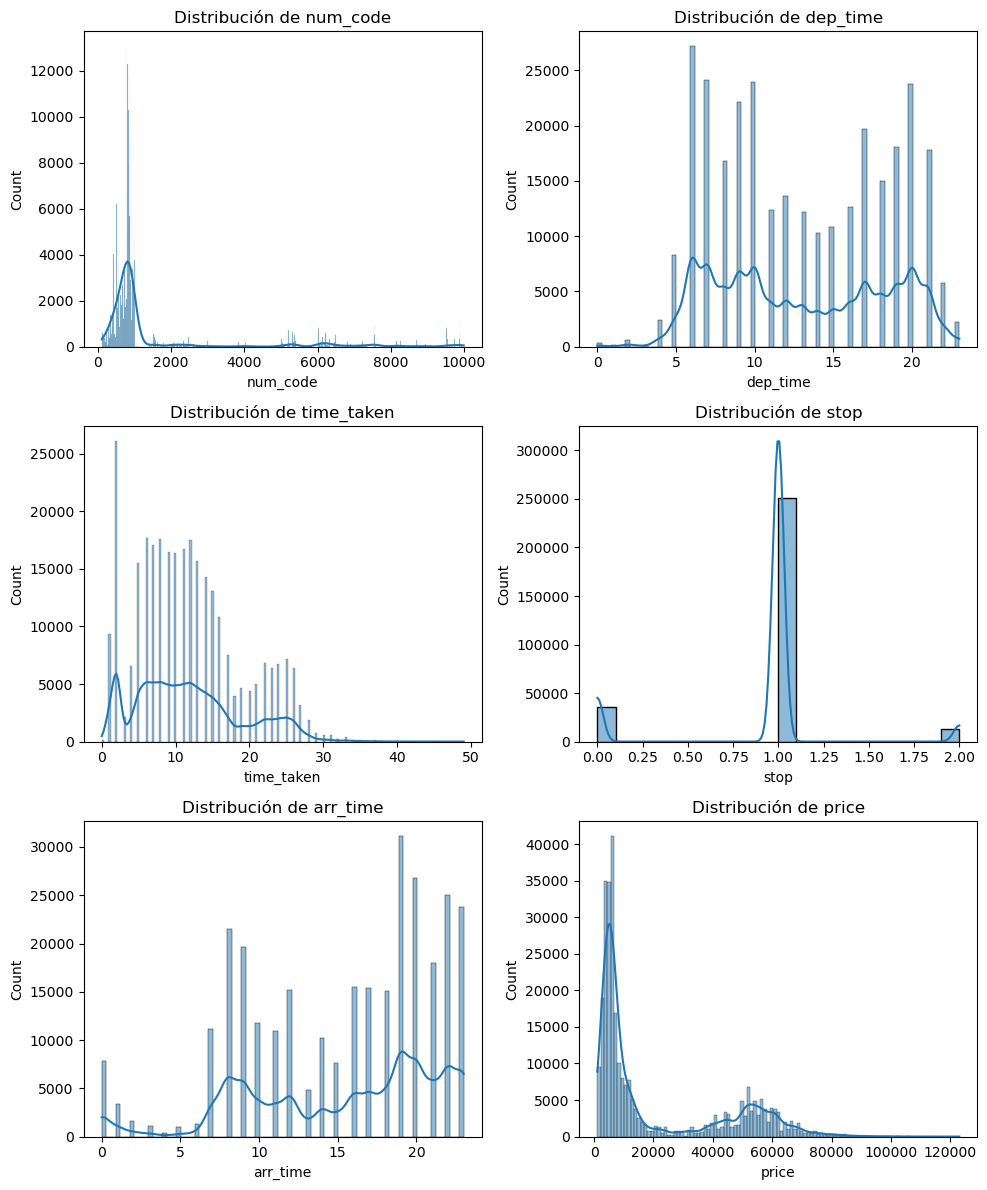

In [17]:
num_cols = Vuelos.select_dtypes(include=np.number).columns

n_cols = 2
n_rows = int(np.ceil(len(num_cols)/n_cols))

plt.figure(figsize=(10,4*n_rows))

for i,col in enumerate(num_cols,1):
    plt.subplot(n_rows,n_cols,i)
    sns.histplot(Vuelos[col], kde=True)
    plt.title(f"Distribución de {col}")

plt.tight_layout()
plt.show()

The visualizations reveal clear patterns in flight distribution across different operational variables.

Regarding departure time, there are two main peaks between 5:00–10:00 and 15:00–20:00, suggesting higher demand during morning and afternoon periods.

In terms of flight duration, most flights fall within the 0 to 20-hour range, indicating that short- to medium-haul flights are the most common.

For the number of stops, the majority of flights have one stop, which may reflect a balance between cost efficiency and travel time.

Finally, arrival times are mostly concentrated between 18:00 and 23:00, likely aligned with passenger convenience and scheduling preferences.

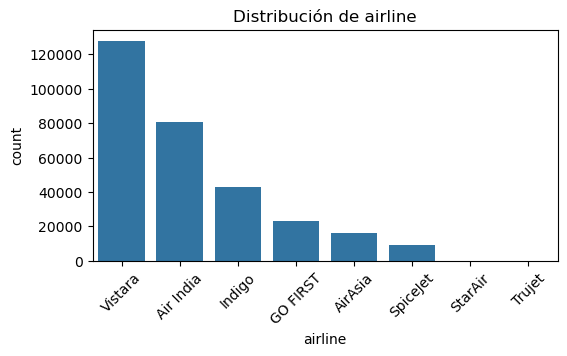

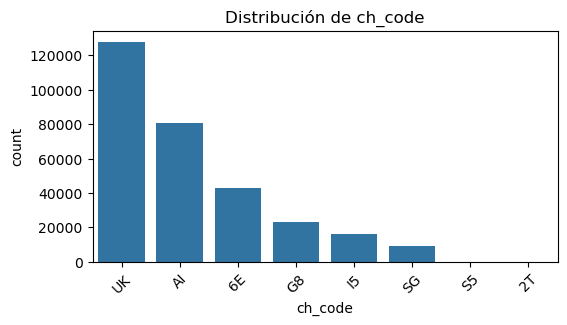

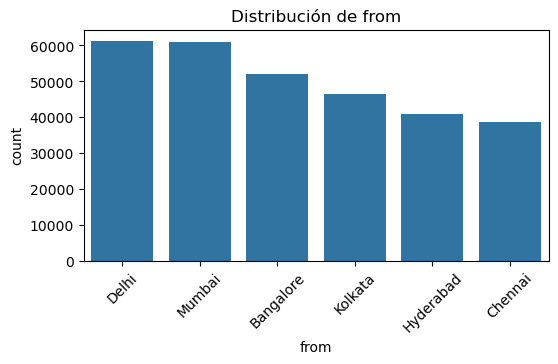

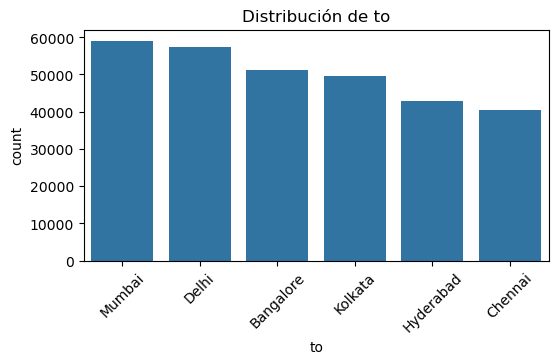

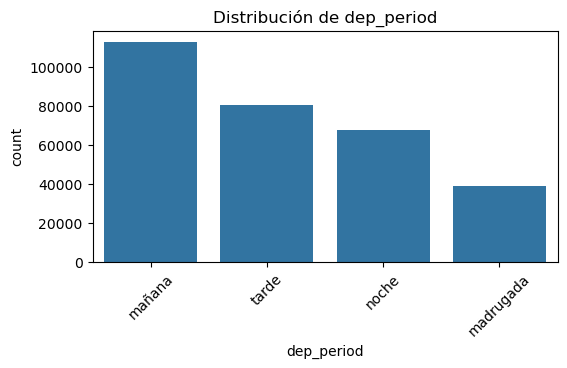

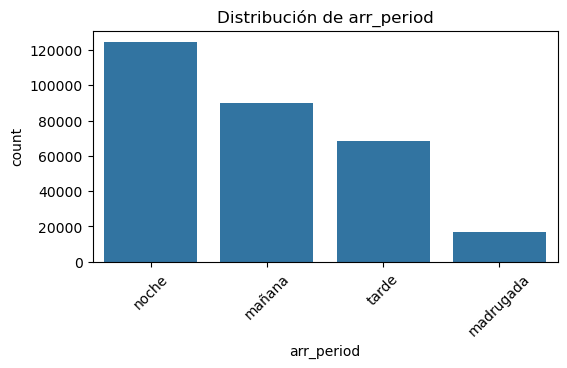

In [82]:
cat_cols = Vuelos.select_dtypes(include=["category","object"]).columns

for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(data=Vuelos, x=col, order=Vuelos[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f"Distribución de {col}")
    plt.show()

The charts show relevant patterns in airline operations.

Vistara has the highest number of flights, suggesting a stronger presence within the dataset. Consistently, the flight code UK appears most frequently, which aligns with this airline’s operations.

Regarding destinations, the distribution is relatively consistent; however, there is a slight concentration of flights to cities such as Delhi and Mumbai, which may indicate higher demand in these locations.

Finally, the time distribution shows that most flights depart in the morning and arrive at night, suggesting scheduling strategies aligned with passenger convenience and operational efficiency.

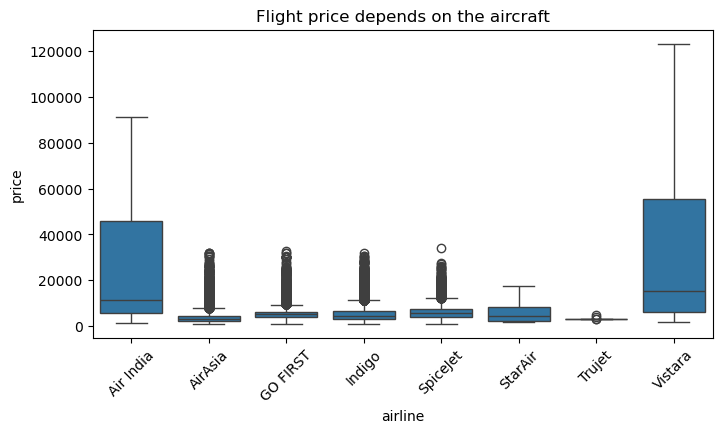

In [18]:
plt.figure(figsize=(8,4))
sns.boxplot(data=Vuelos, x="airline", y="price")
plt.xticks(rotation=45)
plt.title("Flight price depends on the aircraft")
plt.show()

The chart shows that Vistara exhibits more consistent pricing, a pattern that is also observed in Air India.

In contrast, other airlines display a higher number of outliers, indicating greater price variability.

This could be explained by more dynamic pricing strategies, demand fluctuations, or differences in service segmentation, such as travel classes or availability.

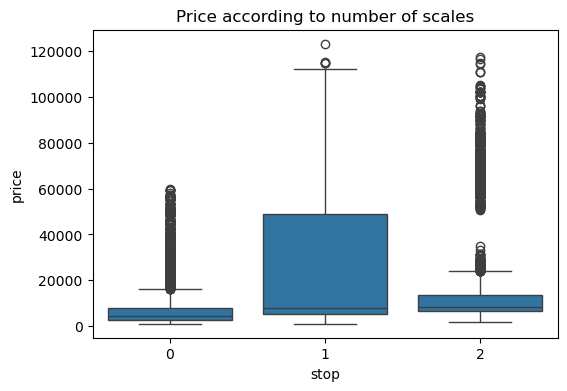

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(data=Vuelos, x="stop", y="price")
plt.title("Price according to number of scales")
plt.show()

The chart shows that flights with one stop are mostly concentrated below the 60,000 price range, with relatively few cases exceeding higher values.

Non-stop flights tend to remain within a more limited price range, not exceeding 60,000, which suggests greater price stability for these routes.

In contrast, flights with two stops exhibit higher price dispersion, indicating less stable pricing behavior, likely influenced by factors such as longer duration or route complexity.

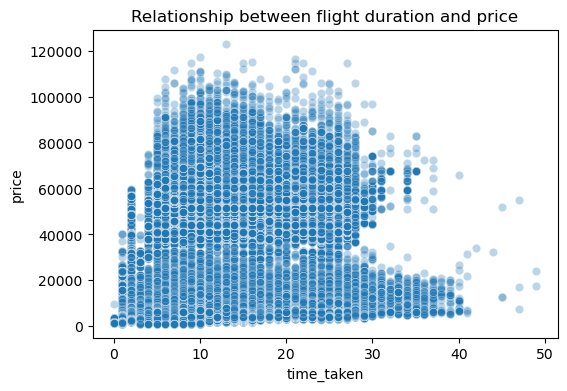

In [20]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=Vuelos, x="time_taken", y="price", alpha=0.3)
plt.title("Relationship between flight duration and price")
plt.show()

The chart shows the relationship between flight duration and price, where a moderate positive trend can be observed, indicating that longer flights tend to have higher prices.

However, there is a high dispersion in the data, as flights with similar durations can have very different prices, suggesting that duration is not the only factor influencing pricing.

Most flights are concentrated between 5 and 25 hours, with prices typically ranging from 20,000 to 90,000.

Additionally, there are some outliers representing long-duration flights with very high prices, likely associated with complex routes or premium services.

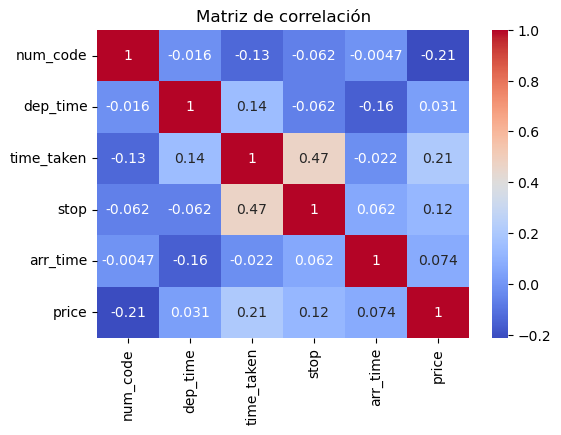

In [21]:
plt.figure(figsize=(6,4))
sns.heatmap(Vuelos.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

The correlation matrix shows that most variables have low correlation values, indicating weak linear relationships between them.

The highest correlation observed is 0.47 between flight duration (time_taken) and number of stops, suggesting a moderate relationship, which aligns with the expectation that flights with more stops tend to take longer.

The relationship between flight duration and price shows a weak positive correlation of 0.21, indicating that duration has some influence on price, but it is not a strong determining factor.

Finally, the correlation between departure time (dep_time) and price is very low (0.03), suggesting that departure time has minimal impact on price variation.  

In [22]:
Vuelos_corr = Vuelos.copy()

cat_cols = Vuelos_corr.select_dtypes(include=["object","category"]).columns

for col in cat_cols:
    Vuelos_corr[col] = Vuelos_corr[col].astype("category").cat.codes

In [23]:
corr_price = Vuelos_corr.corr()["price"].sort_values(ascending=False)
print(corr_price)

price         1.000000
ch_code       0.311008
airline       0.243711
time_taken    0.205324
stop          0.119798
arr_time      0.074238
arr_period    0.069457
dep_period    0.032253
dep_time      0.031252
to            0.004895
from          0.004683
date         -0.091917
num_code     -0.212865
Name: price, dtype: float64


When analyzing the correlation with the price variable, no strong linear relationships are observed, suggesting that price is influenced by multiple factors.

The highest positive correlations are found with ch_code (0.31) and airline (0.24), indicating that airline-related features may have a moderate impact on pricing, likely reflecting brand positioning or service segmentation.

Flight duration (time_taken) shows a weak positive correlation (0.20), suggesting that longer flights tend to be more expensive, although this relationship is not strong.

Other variables such as number of stops (stop) (0.11) and arrival time features (arr_time, arr_period) have minimal influence on price.

On the other hand, variables like date (-0.09) and num_code (-0.21) show weak negative correlations, indicating a slight inverse relationship.

Finally, origin (from) and destination (to) have near-zero correlation values, suggesting no significant linear relationship with price.

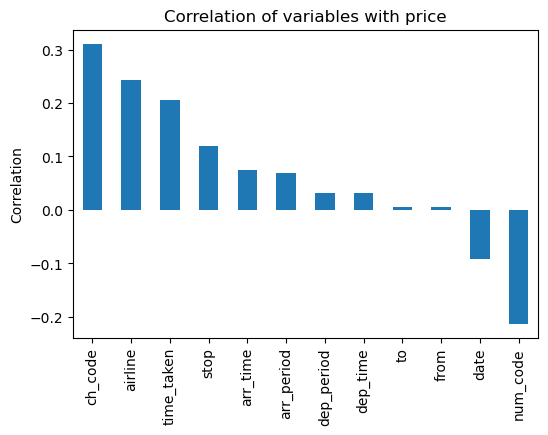

In [24]:
plt.figure(figsize=(6,4))
corr_price.drop("price").plot(kind="bar")
plt.title("Correlation of variables with price")
plt.ylabel("Correlation")
plt.show()

We graphed the correlation and saw that the variables date and num_code are negative, so they will not be relevant within our model.

In [25]:
## We created the variables for the day of the week and the month of the flight.

Vuelos["day_of_week"] = Vuelos["date"].dt.dayofweek
Vuelos["month"] = Vuelos["date"].dt.month


We created two variables for the day of the week and month in which the flight takes place, taking into account that this data can be decisive for the variation of the price.

### Feature Engineering

In [28]:
def prepare_data(df):

    data = df.copy()

    # -------- CLEANING --------

    data["price"] = pd.to_numeric(data["price"], errors="coerce")
    data["time_taken"] = pd.to_numeric(data["time_taken"], errors="coerce")
    data["stop"] = pd.to_numeric(data["stop"], errors="coerce")

    # -------- HOURS --------

    data["dep_time"] = pd.to_datetime(data["dep_time"], errors="coerce").dt.hour
    data["arr_time"] = pd.to_datetime(data["arr_time"], errors="coerce").dt.hour

    # -------- BUSINESS VARIABLES --------

    data["dep_period"] = pd.cut(
        data["dep_time"],
        bins=[0,6,12,18,24],
        labels=["madrugada","mañana","tarde","noche"],
        include_lowest=True
    )

    data["arr_period"] = pd.cut(
        data["arr_time"],
        bins=[0,6,12,18,24],
        labels=["madrugada","mañana","tarde","noche"],
        include_lowest=True
    )

    # only if the date column exists
    if "date" in data.columns:
        data["day_of_week"] = pd.to_datetime(data["date"]).dt.dayofweek
        data["month"] = pd.to_datetime(data["date"]).dt.month
        data = data.drop(columns=["date"])

    #---------ELIMINATE VARIABLES THAT DO NOT CONTRIBUTE.-----------

    data = data.drop(columns=["ch_code"])

    # -------- REMOVE NULLS --------

    data = data.dropna()

    # -------- ENCODING--------

    data = pd.get_dummies(
        data,
        columns=["airline","from","to","dep_period","arr_period"],
        drop_first=True
    )

    return data

In [29]:
Vuelos_limpio = prepare_data(Vuelos)
Vuelos_limpio.head()

,num_code,dep_time,time_taken,stop,arr_time,price,day_of_week,month,airline_AirAsia,airline_GO FIRST,...,to_Delhi,to_Hyderabad,to_Kolkata,to_Mumbai,dep_period_mañana,dep_period_tarde,dep_period_noche,arr_period_mañana,arr_period_tarde,arr_period_noche
0,868,0,2.0,0,0,25612,4,2,False,False,...,False,False,False,True,False,False,False,False,False,False
1,624,0,2.0,0,0,25612,4,2,False,False,...,False,False,False,True,False,False,False,False,False,False
2,531,0,24.0,1,0,42220,4,2,False,False,...,False,False,False,True,False,False,False,False,False,False
3,839,0,26.0,1,0,44450,4,2,False,False,...,False,False,False,True,False,False,False,False,False,False
4,544,0,6.0,1,0,46690,4,2,False,False,...,False,False,False,True,False,False,False,False,False,False


We created the data cleaning function, where we remove null data, set time ranges, correct data, remove unnecessary variables, and finally change the categorical data types, so that we can perform the analysis with our model.

### Modeling
We trained multiple models to predict flight prices and compared their performance.

In [30]:
# We establish the values y and x

X = Vuelos_limpio.drop(columns=["price"])
y = Vuelos_limpio["price"]

In [31]:
## Divide the dataset into train and test.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
#We create variables

num_cols = X_train.select_dtypes(include=["int64","float64"]).columns
cat_cols = X_train.select_dtypes(include=["object","category"]).columns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [33]:
## We establish the models we will train

from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

modelos = {
    "Ridge": Ridge(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor()
}
from sklearn.pipeline import Pipeline

pipelines = {}

for nombre, modelo in modelos.items():
    
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", modelo)
    ])
    
    pipelines[nombre] = pipeline

In [34]:
## We created the parameters

param_grid = {
    
    "Ridge": {
        "model__alpha": [0.1, 1, 10]
    },
    
    "DecisionTree": {
        "model__max_depth": [5, 10, 20]
    },
    
    "RandomForest": {
        "model__n_estimators": [50, 100],
        "model__max_depth": [10, 20]
    }
}

In [35]:
## We optimize the hyperparameters

from sklearn.model_selection import GridSearchCV

best_models = {}

for nombre, pipeline in pipelines.items():
    
    grid = GridSearchCV(
        pipeline,
        param_grid[nombre],
        cv=3,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    best_models[nombre] = grid

### Model Evaluation
We used MAE, RMSE, and R² to evaluate model performance.

In [36]:
## We evaluate our models

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

resultados = []

for nombre, modelo in best_models.items():

    y_pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    resultados.append({
        "Modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

import pandas as pd
resultados_df = pd.DataFrame(resultados)

resultados_df

,Modelo,MAE,RMSE,R2
0,Ridge,18592.287126,21804.780614,0.074780
1,DecisionTree,14841.792059,18924.612961,0.303059
2,RandomForest,14816.181705,18846.065935,0.308833


The results show that tree-based models, particularly Random Forest, outperform linear models such as Ridge in predicting flight prices.

This is reflected in lower error metrics (MAE and RMSE) and a higher R² score, indicating a better ability to capture complex patterns in the data.

However, the relatively low R² suggests that a significant portion of the price variability is still not explained by the available features.

This indicates that the problem is complex and that flight prices are influenced by additional factors not included in the dataset, such as demand, booking timing, or seasonality.

Therefore, incorporating new features and exploring more advanced modeling techniques would likely improve predictive performance.

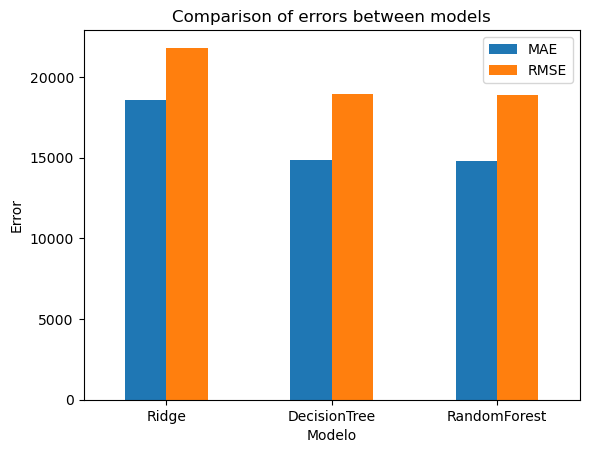

In [37]:
import matplotlib.pyplot as plt

resultados_df.set_index("Modelo")[["MAE","RMSE"]].plot(kind="bar")

plt.title("Comparison of errors between models")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

This chart shows that Ridge is more effective in terms of pricing.

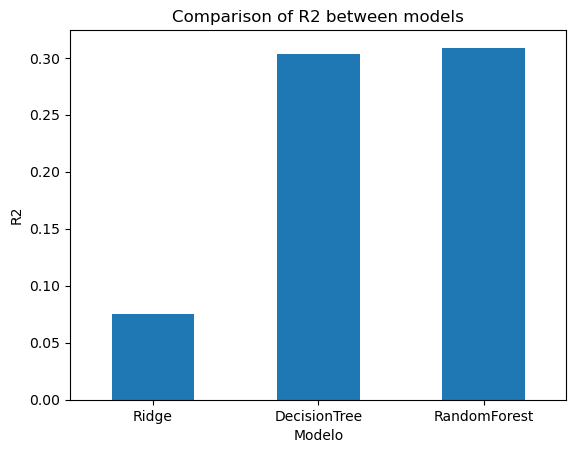

In [38]:
resultados_df.set_index("Modelo")["R2"].plot(kind="bar")

plt.title("Comparison of R2 between models")
plt.ylabel("R2")
plt.xticks(rotation=0)
plt.show()

This graph confirms that Decision Tree and Random Forest models capture more complex, non-linear relationships, leading to better performance compared to linear models.

In [39]:
from sklearn.dummy import DummyRegressor

baseline = DummyRegressor(strategy="mean")

baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)

mae_base = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)

print("Baseline MAE:", mae_base)
print("Baseline RMSE:", rmse_base)
print("Baseline R2:", r2_base)

Baseline MAE: 19720.327039361928
Baseline RMSE: 22668.905859156326
Baseline R2: -6.478822122790717e-06


In [41]:
baseline_df = pd.DataFrame({
    "Modelo":["Baseline"],
    "MAE":[mae_base],
    "RMSE":[rmse_base],
    "R2":[r2_base]
})

resultados_df = pd.concat([resultados_df, baseline_df], ignore_index=True)

In [42]:
resultados_df.head()

,Modelo,MAE,RMSE,R2
0,Ridge,18592.287126,21804.780614,0.074780
1,DecisionTree,14841.792059,18924.612961,0.303059
2,RandomForest,14816.181705,18846.065935,0.308833
3,Baseline,19720.327039,22668.905859,-0.000006


When comparing the baseline model with the trained models, a clear improvement in performance can be observed.

The baseline shows lower performance metrics, indicating limited predictive capability compared to the trained models.

In contrast, the trained models achieve lower error values (MAE and RMSE) and better overall fit, suggesting they are more effective at capturing patterns in the data.

## FINAL CONCLUSION FINAL CONCLUSION

The objective of this project was to analyze and predict flight prices using different features such as airline, duration, number of stops, and time-related variables.

During the analysis, I performed data cleaning, exploratory data analysis, and feature engineering to better understand the structure and patterns in the data.

One key finding was that flight pricing is influenced by multiple factors, with no strong linear relationships between most variables. For example, duration and number of stops showed some influence, but overall correlations were relatively low, indicating a complex pricing structure.

Additionally, I observed that price distributions are highly variable, with the presence of outliers likely driven by real-world factors such as demand, route complexity, and airline strategies.

When comparing models, tree-based approaches like Random Forest outperformed linear models, as they were better able to capture non-linear relationships and interactions between variables.

However, the relatively low R² suggests that a significant portion of price variability remains unexplained, indicating that additional features such as demand, seasonality, or booking timing could improve the model.

From a business perspective, this analysis shows that flight pricing is a complex problem influenced by multiple interacting factors, and that more advanced models and richer datasets are needed for more accurate predictions.

As a next step, I would focus on incorporating additional features and improving model tuning to enhance predictive performance.                        